# DynaSent Round-1 Yelp — Dataset Preprocessing
Full pipeline: raw JSONL → EDA → text cleaning → label encoding → save.

**Sections**
1. Setup & imports
2. Load raw data
3. Exploratory Data Analysis  
   3.1 Class distribution  
   3.2 Sentence length distribution  
   3.3 Vocabulary size  
   3.4 Top word frequencies per class  
   3.5 N-gram analysis (bigrams & trigrams)  
   3.6 Vocabulary overlap between classes  
   3.7 POS-tag distribution  
4. Text preprocessing  
5. Label encoding  
6. Save processed data

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install contractions -q

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.2 MB/s eta 0:00:00


In [2]:
import os, re, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk import pos_tag
from nltk.util import ngrams
import contractions

for pkg in ['punkt', 'punkt_tab', 'stopwords', 'averaged_perceptron_tagger']:
    nltk.download(pkg, quiet=True)

# ── Consistent palette ────────────────────────────────────────────────────
CLASS_COLORS = {'negative': '#E24B4A', 'positive': '#1D9E75', 'neutral': '#378ADD'}
CLASSES      = ['negative', 'positive', 'neutral']

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})
print("✓ All imports successful")

✓ All imports successful


## 2. Load Raw Data

In [3]:
df_train_path = "/content/drive/MyDrive/datasets/dynasent-v1.1-round01-yelp-train.jsonl"
df_val_path   = "/content/drive/MyDrive/datasets/dynasent-v1.1-round01-yelp-dev.jsonl"
df_test_path  = "/content/drive/MyDrive/datasets/dynasent-v1.1-round01-yelp-test.jsonl"

df_train_raw = pd.read_json(df_train_path, lines=True)
df_val_raw   = pd.read_json(df_val_path,   lines=True)
df_test_raw  = pd.read_json(df_test_path,  lines=True)

for name, df in [("Train", df_train_raw), ("Val", df_val_raw), ("Test", df_test_raw)]:
    print(f"{name:>5}  {len(df):>7,} rows   cols: {list(df.columns)}")

Train   94,459 rows   cols: ['hit_ids', 'sentence', 'indices_into_review_text', 'model_0_label', 'model_0_probs', 'text_id', 'review_rating', 'label_distribution', 'gold_label', 'review_id']
  Val    3,600 rows   cols: ['hit_ids', 'sentence', 'indices_into_review_text', 'model_0_label', 'model_0_probs', 'text_id', 'review_rating', 'label_distribution', 'gold_label', 'review_id']
 Test    3,600 rows   cols: ['hit_ids', 'sentence', 'indices_into_review_text', 'model_0_label', 'model_0_probs', 'text_id', 'review_rating', 'label_distribution', 'gold_label', 'review_id']


In [4]:
VALID_LABELS = {'negative', 'positive', 'neutral'}

def prepare_split(df: pd.DataFrame) -> pd.DataFrame:
    """Keep only sentence + gold_label; drop rows with unknown/missing labels."""
    out = df[['sentence', 'gold_label']].copy()
    out = out.dropna(subset=['sentence', 'gold_label'])
    out = out[out['gold_label'].isin(VALID_LABELS)].reset_index(drop=True)
    out['sentence'] = out['sentence'].astype(str)
    return out

df_train = prepare_split(df_train_raw)
df_val   = prepare_split(df_val_raw)
df_test  = prepare_split(df_test_raw)

print(f"After filtering → Train: {len(df_train):,}  |  Val: {len(df_val):,}  |  Test: {len(df_test):,}")
df_train.head(3)

After filtering → Train: 80,488  |  Val: 3,600  |  Test: 3,600


,sentence,gold_label
0,Roto-Rooter is always good when you need someo...,positive
1,It's so worth the price of cox service over he...,positive
2,"I placed my order of ""sticky ribs"" as an appet...",neutral


## 3. Exploratory Data Analysis

### 3.1 Class Distribution

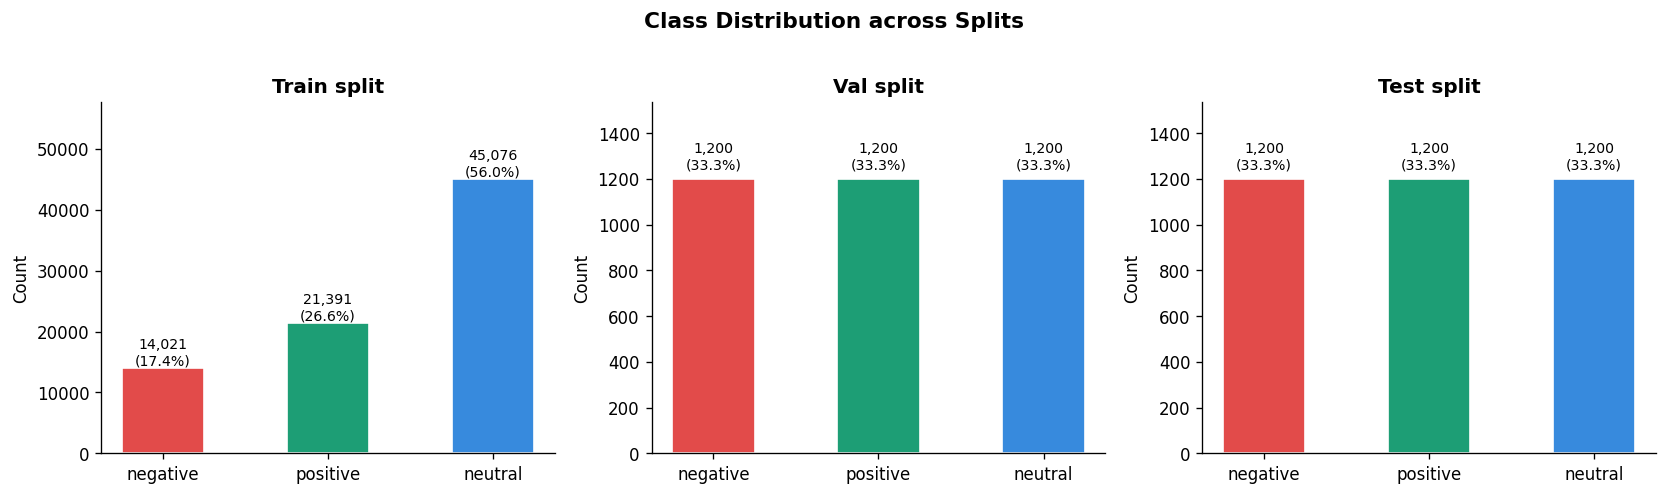

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, df) in zip(axes, [("Train", df_train), ("Val", df_val), ("Test", df_test)]):
    counts = df['gold_label'].value_counts().reindex(CLASSES)
    bars = ax.bar(counts.index, counts.values,
                  color=[CLASS_COLORS[c] for c in CLASSES], width=0.5, edgecolor='white')
    ax.set_title(f'{name} split', fontweight='bold')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=8.5)
    ax.set_ylim(0, counts.max() * 1.28)

plt.suptitle('Class Distribution across Splits', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Sentence Length Distribution

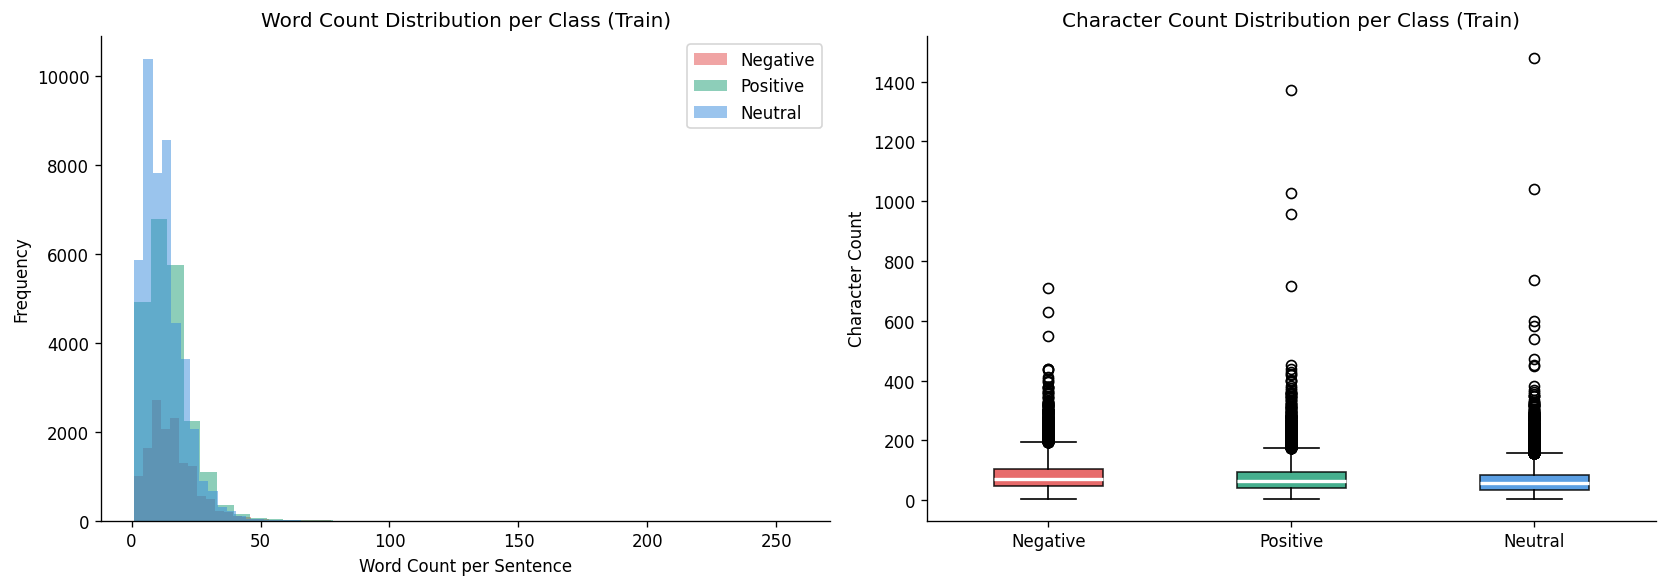


Word count summary — Train split:
              count   mean   std  min  25%   50%   75%    max
gold_label                                                   
negative    14021.0  15.55  9.55  1.0  9.0  14.0  20.0  140.0
neutral     45076.0  12.26  7.71  1.0  7.0  11.0  16.0  145.0
positive    21391.0  14.07  8.92  1.0  8.0  13.0  18.0  258.0


In [6]:
for df in [df_train, df_val, df_test]:
    df['word_count'] = df['sentence'].str.split().str.len()
    df['char_count'] = df['sentence'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram — word count
for cls in CLASSES:
    sub = df_train[df_train['gold_label'] == cls]['word_count']
    axes[0].hist(sub, bins=40, alpha=0.5, label=cls.capitalize(),
                 color=CLASS_COLORS[cls], edgecolor='none')
axes[0].set_xlabel('Word Count per Sentence')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Word Count Distribution per Class (Train)')
axes[0].legend()

# Box plot — character count
data = [df_train[df_train['gold_label'] == c]['char_count'].values for c in CLASSES]
bp   = axes[1].boxplot(data, patch_artist=True, widths=0.45,
                       medianprops={'color': 'white', 'linewidth': 2})
for patch, cls in zip(bp['boxes'], CLASSES):
    patch.set_facecolor(CLASS_COLORS[cls])
    patch.set_alpha(0.82)
axes[1].set_xticklabels([c.capitalize() for c in CLASSES])
axes[1].set_ylabel('Character Count')
axes[1].set_title('Character Count Distribution per Class (Train)')

plt.tight_layout()
plt.show()

# Stats table
print("\nWord count summary — Train split:")
print(df_train.groupby('gold_label')['word_count'].describe().round(2).to_string())

### 3.3 Vocabulary Size

Category               Unique vocab     Total tokens
----------------------------------------------------
All classes                  27,774
  negative                   12,521          221,562
  positive                   14,070          303,113
  neutral                    20,807          553,703


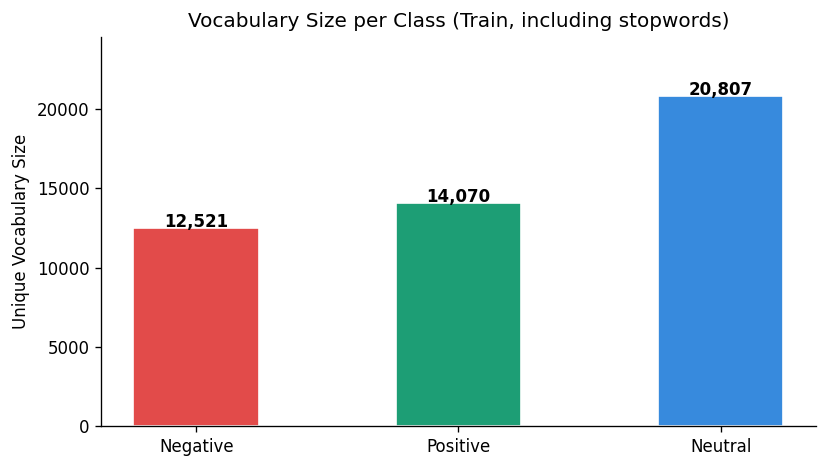

In [7]:
stop_words = set(stopwords.words('english'))

def tokenize(text: str, lower: bool = True) -> list:
    return re.findall(r'\b[a-z]+\b', text.lower() if lower else text)

# Per-class vocabulary (all tokens, including stopwords)
vocab_per_class = {
    cls: set(t for sent in df_train[df_train['gold_label'] == cls]['sentence']
             for t in tokenize(sent))
    for cls in CLASSES
}
vocab_all = set.union(*vocab_per_class.values())

print(f"{'Category':<20} {'Unique vocab':>14}   {'Total tokens':>14}")
print("-" * 52)
print(f"{'All classes':<20} {len(vocab_all):>14,}")
for cls in CLASSES:
    total = sum(1 for s in df_train[df_train['gold_label']==cls]['sentence'] for _ in tokenize(s))
    print(f"  {cls:<18} {len(vocab_per_class[cls]):>14,}   {total:>14,}")

fig, ax = plt.subplots(figsize=(7, 4))
vals = [len(vocab_per_class[c]) for c in CLASSES]
bars = ax.bar([c.capitalize() for c in CLASSES], vals,
              color=[CLASS_COLORS[c] for c in CLASSES], width=0.48, edgecolor='white')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f'{v:,}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Unique Vocabulary Size')
ax.set_title('Vocabulary Size per Class (Train, including stopwords)')
ax.set_ylim(0, max(vals) * 1.18)
plt.tight_layout()
plt.show()

### 3.4 Top Word Frequencies per Class

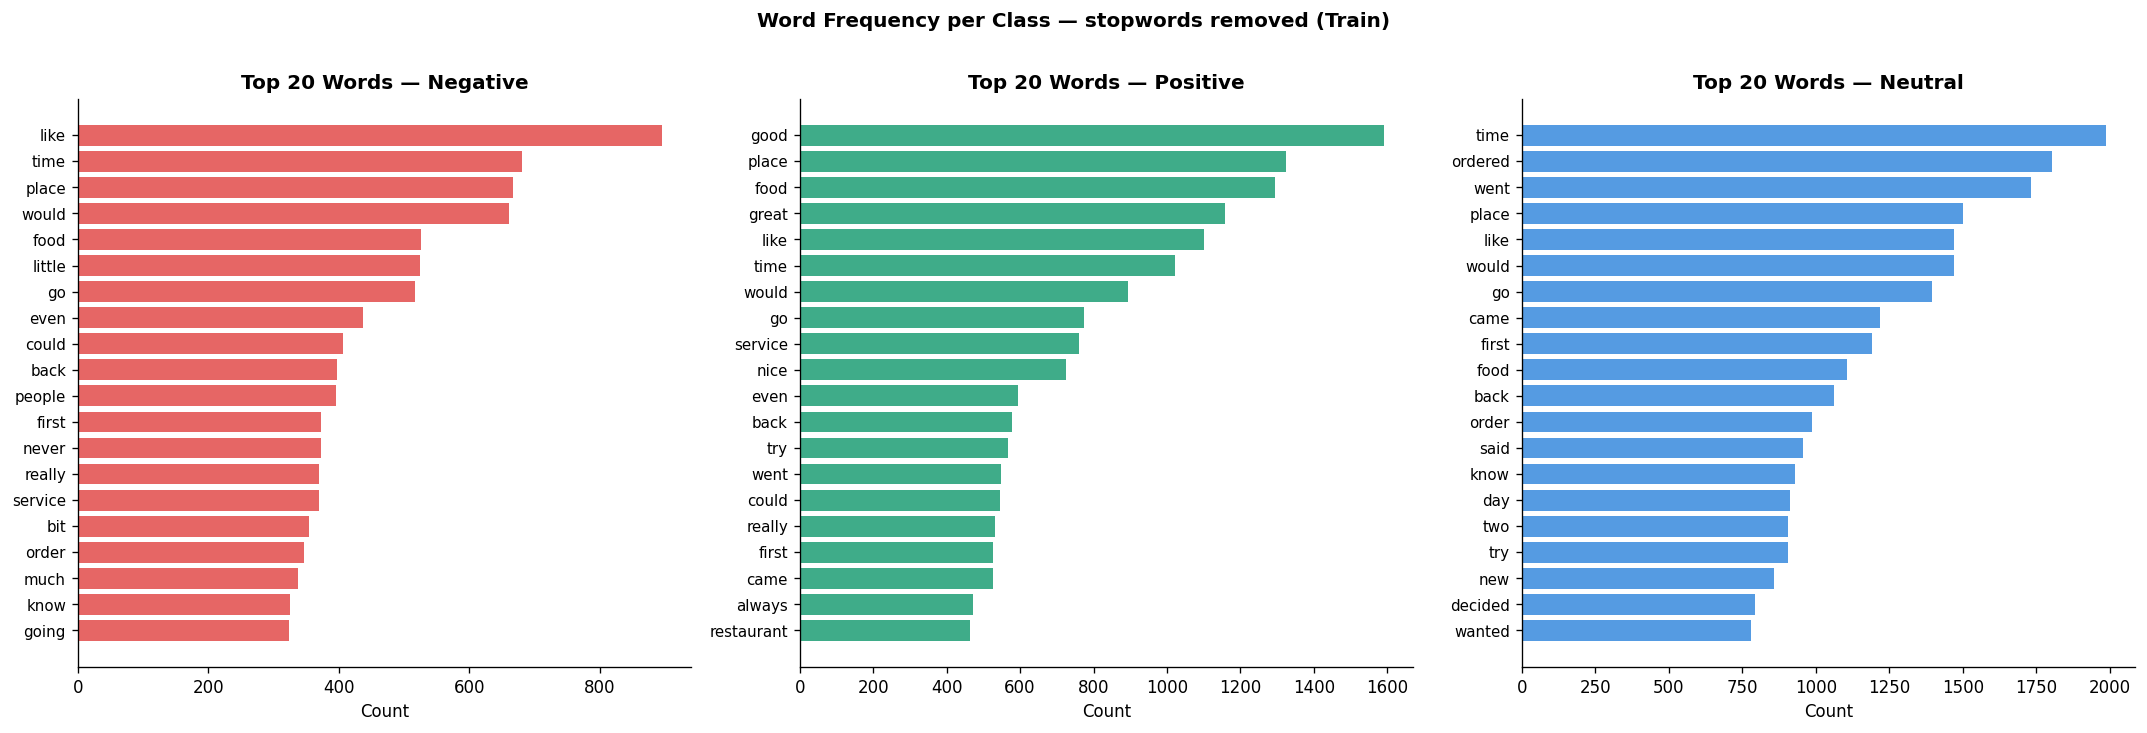

In [8]:
STOP_EXT = stop_words | {'s', 'n', 't', 're', 've', 'll', 'one', 'get', 'got', 'also', 'i', 'us'}
TOP_N    = 20

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, cls in zip(axes, CLASSES):
    tokens = [t for s in df_train[df_train['gold_label']==cls]['sentence']
              for t in tokenize(s) if t not in STOP_EXT and len(t) > 1]
    words, counts = zip(*Counter(tokens).most_common(TOP_N))
    ax.barh(list(reversed(words)), list(reversed(counts)),
            color=CLASS_COLORS[cls], alpha=0.85, edgecolor='none')
    ax.set_title(f'Top {TOP_N} Words — {cls.capitalize()}', fontweight='bold')
    ax.set_xlabel('Count')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Word Frequency per Class — stopwords removed (Train)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.5 N-gram Analysis — Bigrams & Trigrams per Class

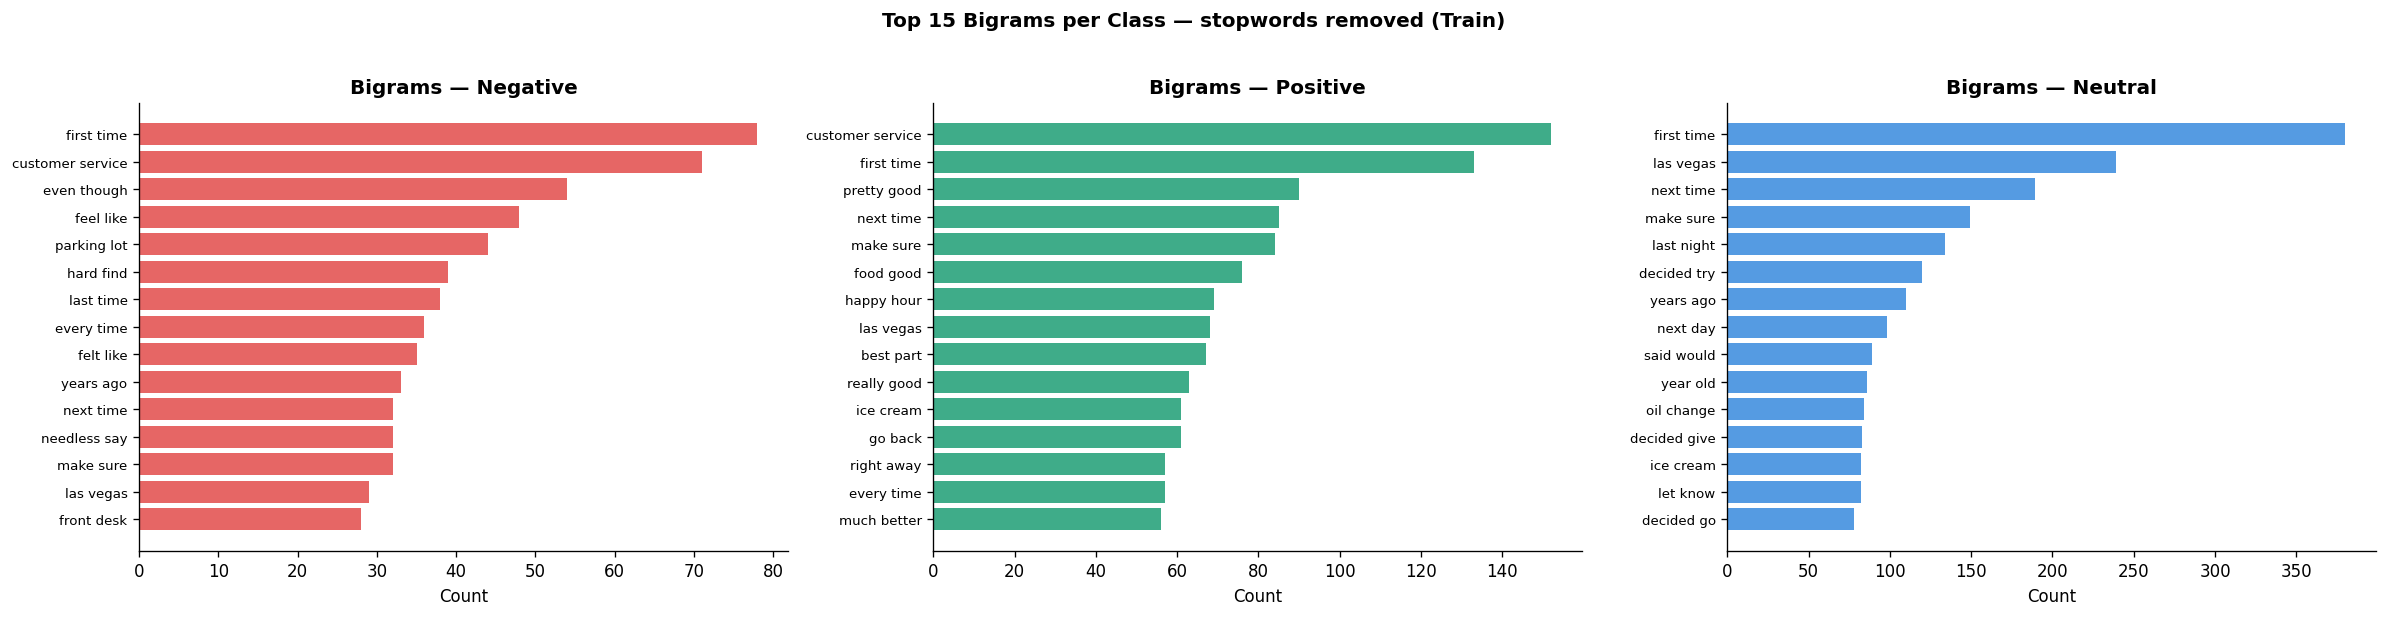

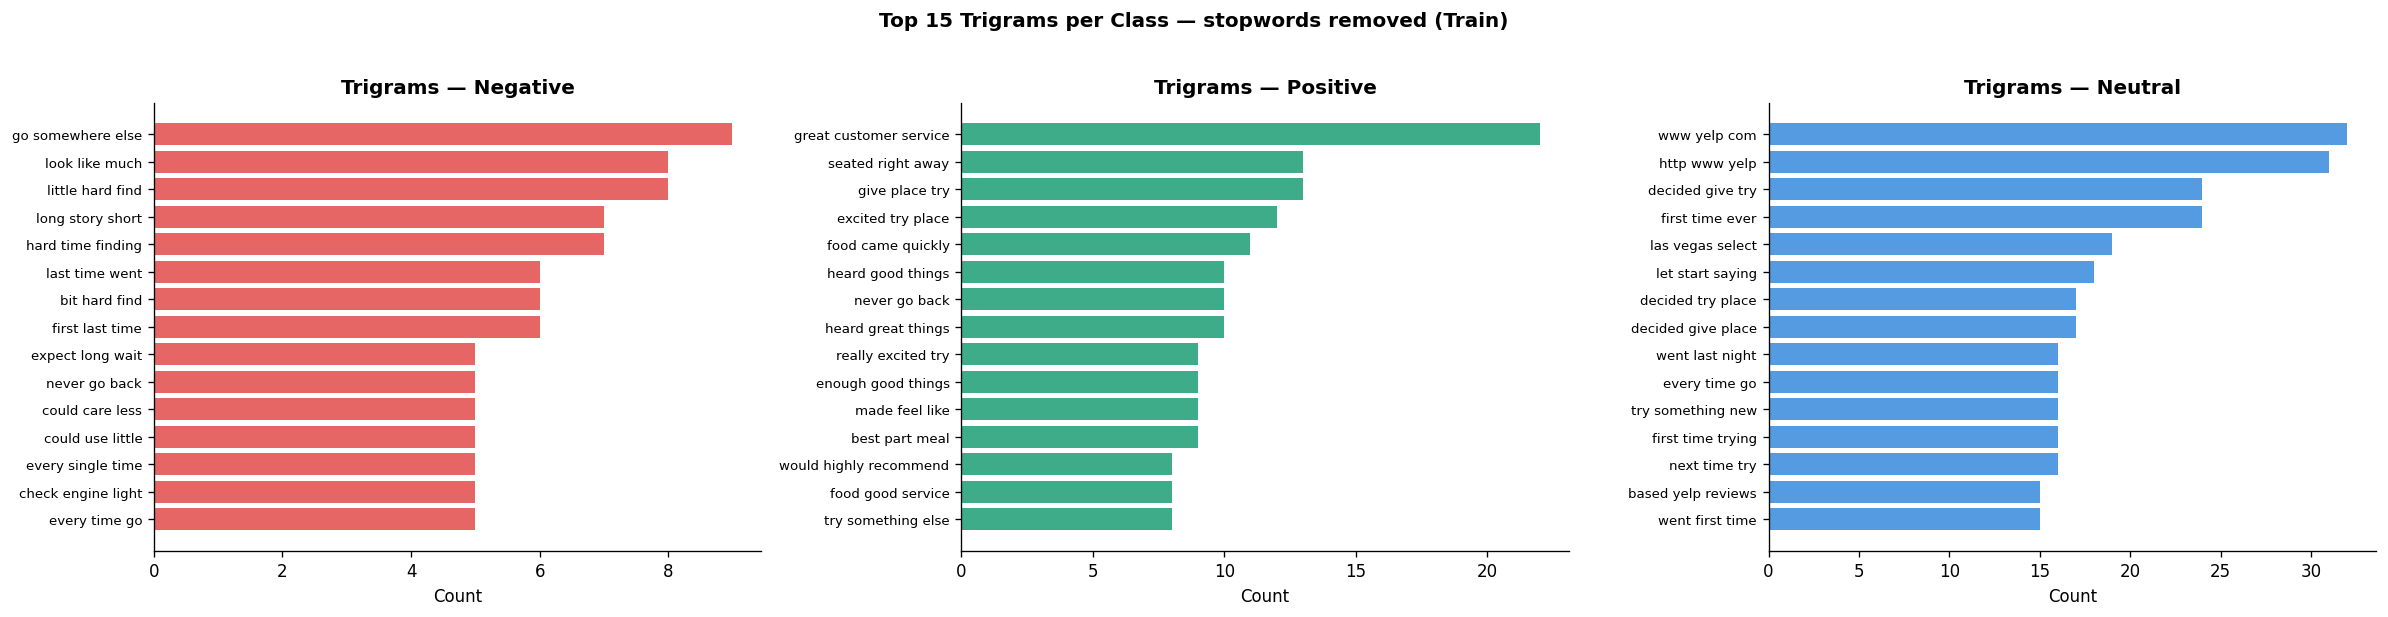

In [9]:
def top_ngrams(series, n, top_k=15):
    all_ng = []
    for text in series:
        toks = [t for t in tokenize(text) if t not in STOP_EXT and len(t) > 1]
        all_ng.extend(list(ngrams(toks, n)))
    return Counter(all_ng).most_common(top_k)

for n, label in [(2, 'Bigrams'), (3, 'Trigrams')]:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    for ax, cls in zip(axes, CLASSES):
        freq = top_ngrams(df_train[df_train['gold_label']==cls]['sentence'], n=n)
        if not freq:
            ax.set_visible(False)
            continue
        grams, counts = zip(*freq)
        labels_ng = [' '.join(g) for g in grams]
        ax.barh(list(reversed(labels_ng)), list(reversed(counts)),
                color=CLASS_COLORS[cls], alpha=0.85, edgecolor='none')
        ax.set_title(f'{label} — {cls.capitalize()}', fontweight='bold')
        ax.set_xlabel('Count')
        ax.tick_params(axis='y', labelsize=8)
    fig.suptitle(f'Top 15 {label} per Class — stopwords removed (Train)',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

### 3.6 Vocabulary Overlap Between Classes

Pair                                 Shared words     Jaccard
--------------------------------------------------------------
  negative ↔ positive                        7,735      0.4102
  negative ↔ neutral                         8,969      0.3682
  positive ↔ neutral                         9,927      0.3979

  All three classes share: 7,007 words

Words exclusive to each class (not in either other class):
  negative    : 2,824 exclusive words   top 10: []
  positive    : 3,415 exclusive words   top 10: []
  neutral     : 8,918 exclusive words   top 10: []


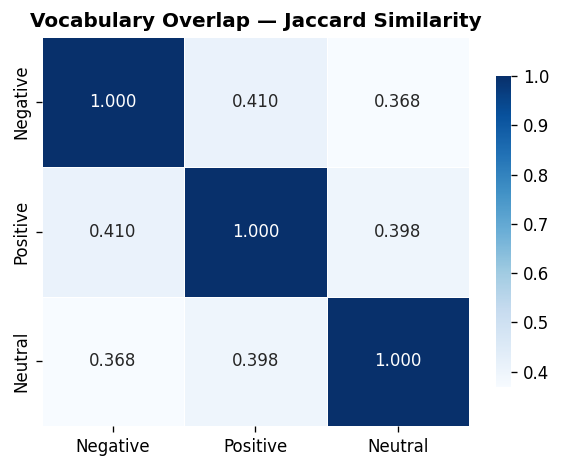

In [10]:
def jaccard(a: set, b: set) -> float:
    union = a | b
    return len(a & b) / len(union) if union else 0.0

pairs = list(combinations(CLASSES, 2))
print(f"{'Pair':<34} {'Shared words':>14}  {'Jaccard':>10}")
print("-" * 62)
for a, b in pairs:
    shared = vocab_per_class[a] & vocab_per_class[b]
    j      = jaccard(vocab_per_class[a], vocab_per_class[b])
    print(f"  {a} ↔ {b:<22} {len(shared):>14,}  {j:>10.4f}")

three_way = vocab_per_class['negative'] & vocab_per_class['positive'] & vocab_per_class['neutral']
print(f"\n  All three classes share: {len(three_way):,} words")

print("\nWords exclusive to each class (not in either other class):")
for cls in CLASSES:
    others    = set.union(*[vocab_per_class[c] for c in CLASSES if c != cls])
    exclusive = vocab_per_class[cls] - others
    freq_cls  = Counter(t for s in df_train[df_train['gold_label']==cls]['sentence']
                        for t in tokenize(s))
    top_exc   = [w for w, _ in freq_cls.most_common(500)
                 if w in exclusive and w not in STOP_EXT and len(w) > 2][:10]
    print(f"  {cls:<12}: {len(exclusive):,} exclusive words   top 10: {top_exc}")

# Jaccard heatmap
jac_mat = np.array([[jaccard(vocab_per_class[a], vocab_per_class[b])
                     for b in CLASSES] for a in CLASSES])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(jac_mat, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=[c.capitalize() for c in CLASSES],
            yticklabels=[c.capitalize() for c in CLASSES],
            ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Vocabulary Overlap — Jaccard Similarity', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Text Preprocessing

Steps applied to every sentence:
1. **Expand contractions** — *don't* → *do not*
2. **Lowercase**
3. **Remove URLs** and email addresses
4. **Remove HTML tags**
5. **Strip non-alphabetic characters** (keep single spaces)
6. **Collapse whitespace**

In [11]:
def clean_text(text: str) -> str:
    text = contractions.fix(text)             # 1. expand contractions
    text = text.lower()                        # 2. lowercase
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # 3. URLs
    text = re.sub(r'\S+@\S+', '', text)      # 3. emails
    text = re.sub(r'<[^>]+>', '', text)        # 4. HTML
    text = re.sub(r'[^a-z\s]', ' ', text)     # 5. non-alpha
    text = re.sub(r'\s+', ' ', text).strip()  # 6. whitespace
    return text

# Quick sanity check
examples = [
    "Don't go there, it's terrible!!!",
    "I can't believe how amazing this is! Visit https://yelp.com/r/123",
    "It's not bad, but I wouldn't go back — ever.",
    "food=great, service=awful",
]
print(f"{'Original':<55}  {'Cleaned'}")
print("-" * 100)
for s in examples:
    print(f"{s:<55}  {clean_text(s)}")

Original                                                 Cleaned
----------------------------------------------------------------------------------------------------
Don't go there, it's terrible!!!                         do not go there it is terrible
I can't believe how amazing this is! Visit https://yelp.com/r/123  i cannot believe how amazing this is visit
It's not bad, but I wouldn't go back — ever.             it is not bad but i would not go back ever
food=great, service=awful                                food great service awful


In [12]:
# Apply to all splits
for df, name in [(df_train, 'Train'), (df_val, 'Val'), (df_test, 'Test')]:
    df['sentence_clean'] = df['sentence'].apply(clean_text)
    before = len(df)
    df.drop(df[df['sentence_clean'].str.len() == 0].index, inplace=True)
    df.reset_index(drop=True, inplace=True)
    after  = len(df)
    removed = before - after
    print(f"{name:>5}:  {before:>7,} → {after:>7,}  (removed {removed} empty after cleaning)")

df_train[['sentence', 'sentence_clean', 'gold_label']].head(4)

Train:   80,488 →  80,416  (removed 72 empty after cleaning)
  Val:    3,600 →   3,597  (removed 3 empty after cleaning)
 Test:    3,600 →   3,595  (removed 5 empty after cleaning)


,sentence,sentence_clean,gold_label
0,Roto-Rooter is always good when you need someo...,roto rooter is always good when you need someo...,positive
1,It's so worth the price of cox service over he...,it is so worth the price of cox service over h...,positive
2,"I placed my order of ""sticky ribs"" as an appet...",i placed my order of sticky ribs as an appetiz...,neutral
3,"There is mandatory valet parking, so make sure...",there is mandatory valet parking so make sure ...,neutral


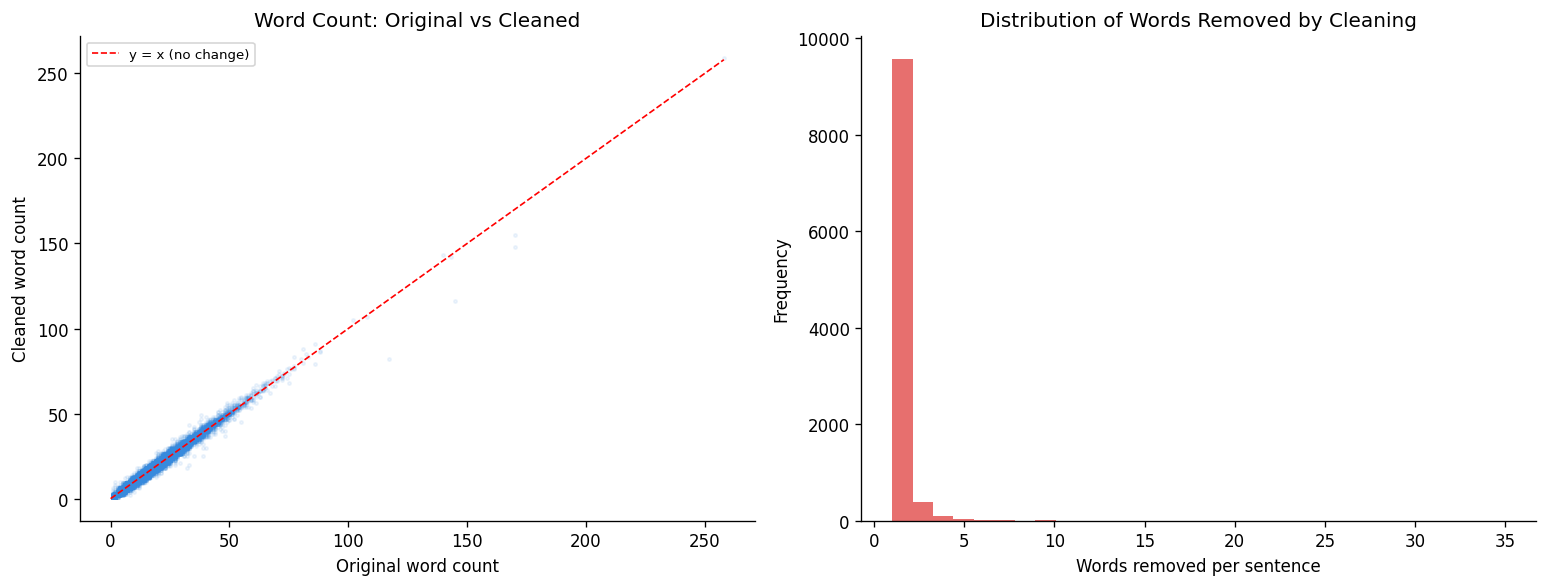

Word count: mean reduction = -0.121   max reduction = 35
Char count: mean reduction = 2.2   max reduction = 1214
Sentences with zero word change: 52,418 / 80,416


In [13]:
# Word count change after cleaning
df_train['word_count_clean'] = df_train['sentence_clean'].str.split().str.len()
df_train['char_count_clean'] = df_train['sentence_clean'].str.len()
delta_words = df_train['word_count'] - df_train['word_count_clean']
delta_chars = df_train['char_count'] - df_train['char_count_clean']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: original vs cleaned word count
axes[0].scatter(df_train['word_count'], df_train['word_count_clean'],
                alpha=0.08, s=4, color='#378ADD')
lim = df_train['word_count'].max()
axes[0].plot([0, lim], [0, lim], 'r--', lw=1, label='y = x (no change)')
axes[0].set_xlabel('Original word count')
axes[0].set_ylabel('Cleaned word count')
axes[0].set_title('Word Count: Original vs Cleaned')
axes[0].legend(fontsize=8)

# Distribution of word-count reduction
axes[1].hist(delta_words[delta_words > 0], bins=30, color='#E24B4A', alpha=0.8, edgecolor='none')
axes[1].set_xlabel('Words removed per sentence')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Words Removed by Cleaning')

plt.tight_layout()
plt.show()

print(f"Word count: mean reduction = {delta_words.mean():.3f}   max reduction = {delta_words.max()}")
print(f"Char count: mean reduction = {delta_chars.mean():.1f}   max reduction = {delta_chars.max()}")
print(f"Sentences with zero word change: {(delta_words==0).sum():,} / {len(df_train):,}")

## 5. Label Encoding

In [14]:
LABEL_TO_ID = {'negative': 0, 'positive': 1, 'neutral': 2}
ID_TO_LABEL = {v: k for k, v in LABEL_TO_ID.items()}

for df in [df_train, df_val, df_test]:
    df['label_id'] = df['gold_label'].map(LABEL_TO_ID).astype(int)

# Verification
print("Label mapping:", LABEL_TO_ID)
print("\nLabel distribution after encoding (Train):")
print(df_train.groupby(['gold_label', 'label_id']).size()
      .rename('count').reset_index().to_string(index=False))

assert all(df['label_id'].isna().sum() == 0 for df in [df_train, df_val, df_test]), \
    "NaN label_ids found — check gold_label values"
print("\n✓ No NaN label_ids across all splits")

Label mapping: {'negative': 0, 'positive': 1, 'neutral': 2}

Label distribution after encoding (Train):
gold_label  label_id  count
  negative         0  14020
   neutral         2  45007
  positive         1  21389

✓ No NaN label_ids across all splits


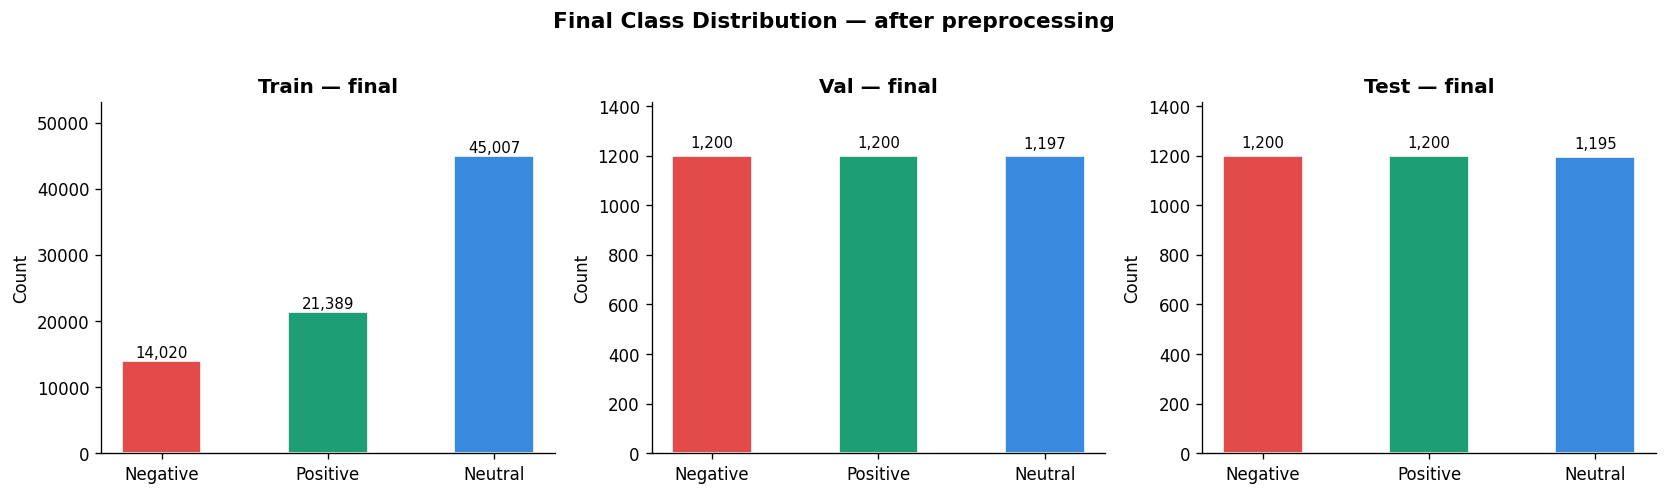

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, df) in zip(axes, [("Train", df_train), ("Val", df_val), ("Test", df_test)]):
    counts = df['gold_label'].value_counts().reindex(CLASSES)
    bars = ax.bar([c.capitalize() for c in CLASSES], counts.values,
                  color=[CLASS_COLORS[c] for c in CLASSES], width=0.48, edgecolor='white')
    ax.set_title(f'{name} — final', fontweight='bold')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{val:,}', ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, counts.max() * 1.18)

plt.suptitle('Final Class Distribution — after preprocessing', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Save Processed Data

In [16]:
SAVE_DIR  = "/content/drive/MyDrive/datasets/processed_dynasent/"
SAVE_COLS = ['sentence', 'sentence_clean', 'gold_label', 'label_id']

os.makedirs(SAVE_DIR, exist_ok=True)

for df, name in [(df_train, 'train'), (df_val, 'val'), (df_test, 'test')]:
    path = os.path.join(SAVE_DIR, f"dynasent_r1_yelp_{name}.csv")
    df[SAVE_COLS].to_csv(path, index=False)
    print(f"  Saved {name:<6}: {len(df):>7,} rows  →  {path}")

label_map_path = os.path.join(SAVE_DIR, "label_map.json")
with open(label_map_path, 'w') as f:
    json.dump(LABEL_TO_ID, f, indent=2)
print(f"  Saved label map         →  {label_map_path}")

  Saved train :  80,416 rows  →  /content/drive/MyDrive/datasets/processed_dynasent/dynasent_r1_yelp_train.csv
  Saved val   :   3,597 rows  →  /content/drive/MyDrive/datasets/processed_dynasent/dynasent_r1_yelp_val.csv
  Saved test  :   3,595 rows  →  /content/drive/MyDrive/datasets/processed_dynasent/dynasent_r1_yelp_test.csv
  Saved label map         →  /content/drive/MyDrive/datasets/processed_dynasent/label_map.json


In [17]:
# ── Final summary ────────────────────────────────────────────────────────────
print("=" * 52)
print("   PREPROCESSING COMPLETE — SUMMARY")
print("=" * 52)
for name, df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    print(f"\n{name} split  ({len(df):,} samples)")
    for cls in CLASSES:
        n = (df['gold_label'] == cls).sum()
        print(f"  {cls:<12} {n:>7,}   ({n/len(df)*100:.1f}%)")
print(f"\nLabel map  : {LABEL_TO_ID}")
print(f"Saved to   : {SAVE_DIR}")

   PREPROCESSING COMPLETE — SUMMARY

Train split  (80,416 samples)
  negative      14,020   (17.4%)
  positive      21,389   (26.6%)
  neutral       45,007   (56.0%)

Val split  (3,597 samples)
  negative       1,200   (33.4%)
  positive       1,200   (33.4%)
  neutral        1,197   (33.3%)

Test split  (3,595 samples)
  negative       1,200   (33.4%)
  positive       1,200   (33.4%)
  neutral        1,195   (33.2%)

Label map  : {'negative': 0, 'positive': 1, 'neutral': 2}
Saved to   : /content/drive/MyDrive/datasets/processed_dynasent/
